# Precificação de Imóveis (King County, EUA) - Comparação entre regressão linear e KNN Regressor.

**Problema preditivo:** estimar o preço de venda (`price`) de um imóvel a partir de suas características físicas e de localização. É um problema de **regressão**, pois o alvo é uma variável numérica contínua, em **dólares americanos (USD)**, já que o dataset descreve o mercado imobiliário do condado de King County (EUA), onde fica Seattle.

**Por que isso importa:** uma estimativa de preço confiável ajuda compradores, vendedores, corretores e bancos (financiamento) a tomar decisões melhores, evitando superavaliação ou subavaliação de um imóvel.



In [78]:
# Garante que o notebook perceba a pasta `src/` e os caminhos relativos (ex.: "data/raw/...") 
# independente de onde o Jupyter foi iniciado, 
# seja na raiz do projeto, seja dentro de notebooks/.
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "src").is_dir() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [ ]:
# Importação de bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import json
from datetime import datetime


# Funções reutilizáveis do projeto, implementadas em src

from src.config import MODEL_DIR, MODEL_FILE, METRICS_FILE
from src.dataset import load_raw_data, save_processed_data, save_final_data
from src.features import (
    clean_data, cap_iqr, add_features, select_final_columns,
    fit_zipcode_faixas, apply_zipcode_faixas,
)
from src.plots import (
    plot_histogram, plot_boxplots, plot_scatter,
    plot_correlation_heatmap, plot_observed_vs_predicted, plot_residuals,
)
from src.modeling.train import train_model, train_knn_model, evaluate_model, evaluate_model2, save_model, save_metrics

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Fase 1 - Análise Exploratória de Dados (EDA)

In [80]:
# Carrega o dataset bruto usando a função de src/dataset.py

df = load_raw_data()

print("INSPEÇÃO INICIAL DO DATASET")
print(f"Shape: {df.shape}")
print(f"\nTipos de dados:\n{df.dtypes}")
print(f"\nValores nulos por coluna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

df.describe()

INSPEÇÃO INICIAL DO DATASET
Shape: (21613, 21)

Tipos de dados:
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Valores nulos por coluna:
sqft_above    2
dtype: int64


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,611.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86","540,088.14",3.37,2.11,"2,079.90","15,106.97",1.49,0.01,0.23,3.41,7.66,"1,788.40",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
std,"2,876,565,571.31","367,127.20",0.93,0.77,918.44,"41,420.51",0.54,0.09,0.77,0.65,1.18,828.13,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"
min,"1,000,102.00","75,000.00",0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00","321,950.00",3.00,1.75,"1,427.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00","450,000.00",3.00,2.25,"1,910.00","7,618.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00","645,000.00",4.00,2.50,"2,550.00","10,688.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00","7,700,000.00",33.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"


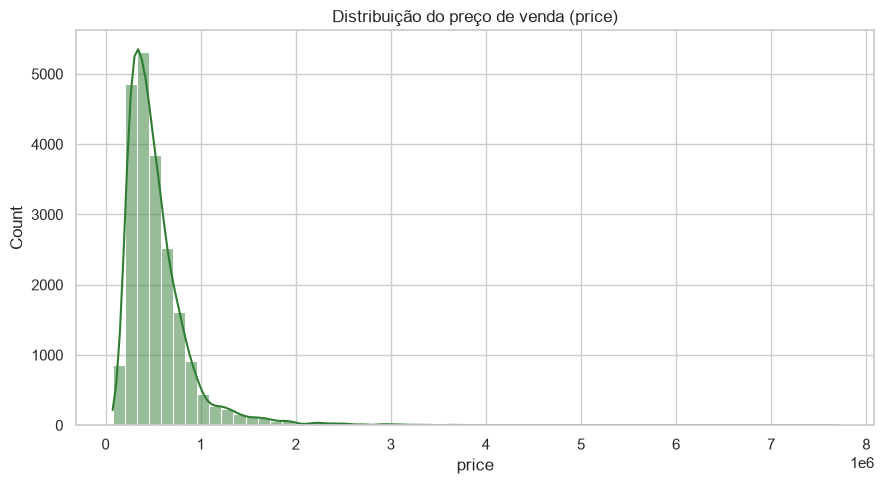

Assimetria (skew) de price: 4.02
Mediana: US$ 450,000   |   Média: US$ 540,088


In [81]:
# Distribuição da variável alvo (price)
# Casas têm preços com forte assimetria à direita (poucas mansões muito caras puxam a média para cima) 
# isso é esperado no mercado imobiliário e já nos avisa que a métrica RMSE será sensível a esses valores extremos.

plot_histogram(df["price"],"Distribuição do preço de venda (price)", "01_distribuicao_price.png")
print(f"Assimetria (skew) de price: {df['price'].skew():.2f}")
print(f"Mediana: US$ {df['price'].median():,.0f}   |   Média: US$ {df['price'].mean():,.0f}")

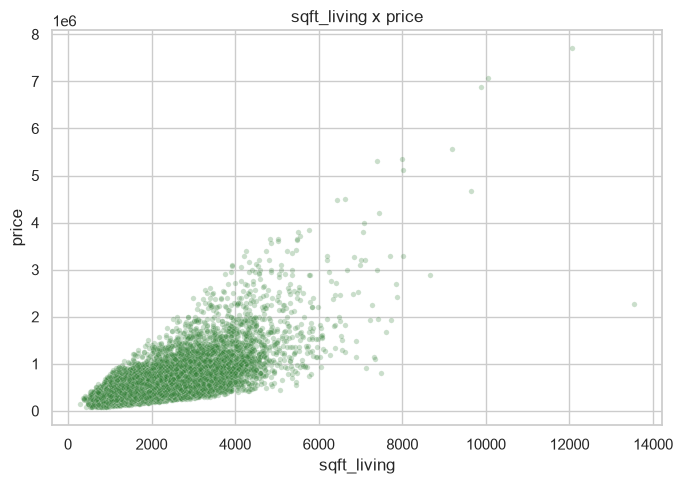

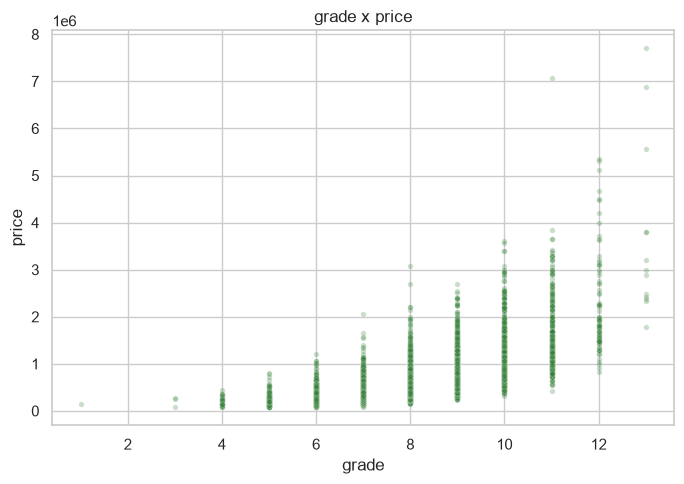

In [82]:
# Dispersão entre variáveis explicativas e a variável alvo.
# Se houvesse uma relação linear forte, esperaríamos ver os pontos formando
# uma "faixa" ao redor de uma reta crescente.

plot_scatter(df, x="sqft_living", y="price", filename="03_scatter_sqftliving_price.png")
plot_scatter(df, x="grade", y="price", filename="03b_scatter_grade_price.png")

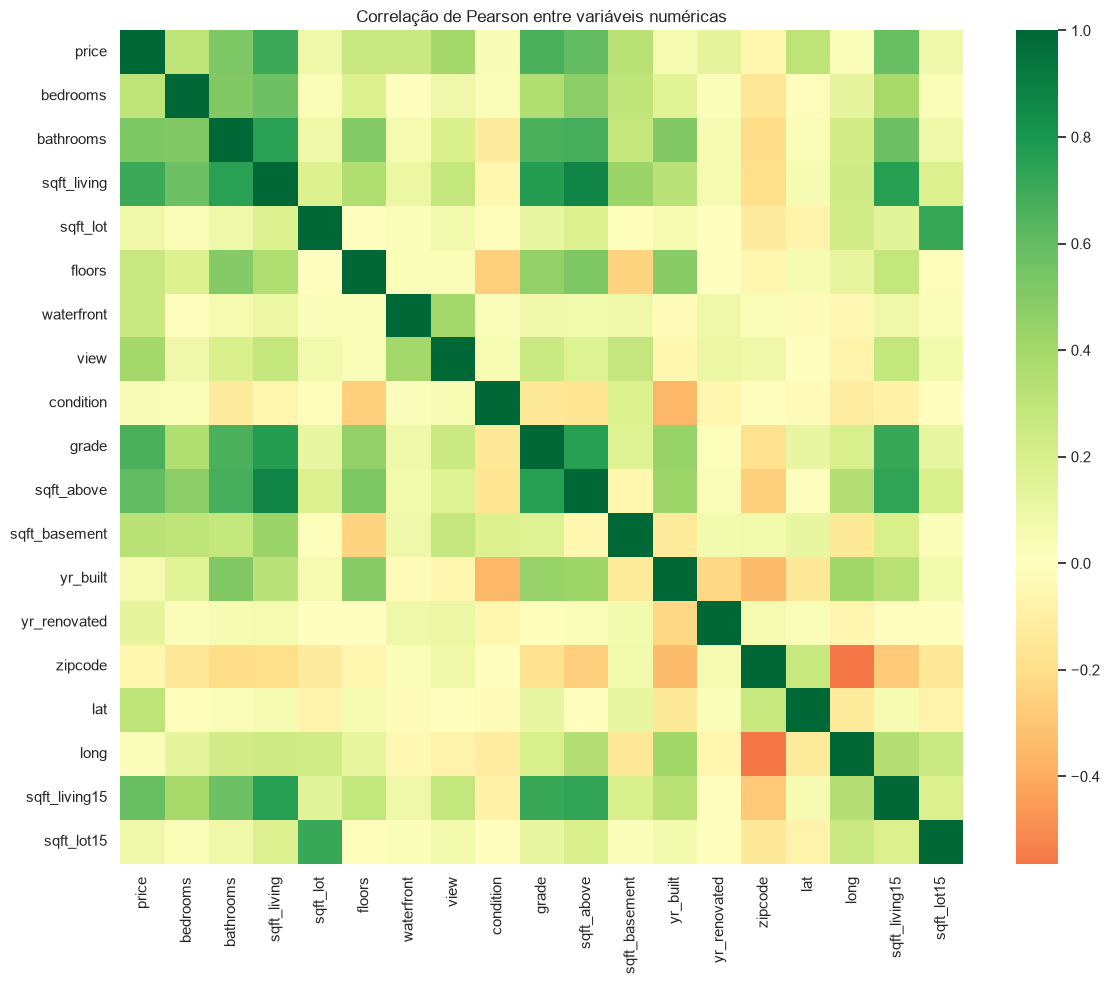

Pares com correlação > 0.7:
sqft_living  sqft_above      0.88
             grade           0.76
             sqft_living15   0.76
grade        sqft_above      0.76
bathrooms    sqft_living     0.75
sqft_above   sqft_living15   0.73
sqft_lot     sqft_lot15      0.72
grade        sqft_living15   0.71
price        sqft_living     0.70
dtype: float64


In [83]:
# Mapa de calor de correlação de Pearson entre as variáveis numéricas. Isso já antecipa o trabalho da Fase 4: pares muito correlacionados
# entre si são candidatos a problema de multicolinearidade.

num_cols = df.select_dtypes(include=np.number).drop(columns=["id"]).columns
plot_correlation_heatmap(df[num_cols], filename="02_correlation_heatmap.png")

corr = df[num_cols].corr()

# Vamos usar a matriz de correlação para identificar pares de variáveis com correlação > 0.7 justamente porque você
# vai perceber que várias delas são muito correlacionadas entre si. Poderiamos usar > 0.8 ou > 0.9, 
# mas isso reduziria muito o número de pares encontrados nesse caso específico.

print("Pares com correlação > 0.7:")
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(pairs[pairs.abs() > 0.7].sort_values(ascending=False))

**Análise crítica dos achados (Fase 1):**

- `price` é fortemente assimétrica à direita (skew ≈ 4.0): a maioria dos imóveis se concentra
  entre US$ 300 mil e US$ 650 mil, mas um pequeno número de mansões acima de US$ 3 milhões
  puxa a média para bem acima da mediana. Isso indica que métricas de erro absoluto (MAE, RMSE)
  serão naturalmente sensíveis a esses poucos imóveis muito caros.
- `sqft_living` e `grade` mostram uma relação visualmente crescente com `price`, confirmando a
  hipótese de que são bons candidatos a preditores fortes.
- O mapa de calor revela que `sqft_living` está fortemente correlacionada com `sqft_above`,
 `bathrooms` e `sqft_living15`. Isso é esperado (todas descrevem "tamanho" do imóvel
  de formas parecidas) e será tratado como multicolinearidade na Fase 4, antes de treinar o
  modelo. Caso contrário, os coeficientes da Regressão Linear ficariam instáveis e difíceis
  de interpretar.

## Fase 2 - Tratamento e Limpeza (Data Prep)

In [84]:
# --- Linhas duplicadas: duplicatas completas (todas as colunas iguais) ---
n_duplicatas = df.duplicated().sum()
print(f"Duplicatas completas encontradas: {n_duplicatas}")

# --- Duplicatas parciais: o mesmo imóvel (mesmo id) aparecendo mais de uma vez ---
n_id_dup = df.duplicated(subset=["id"]).sum()
print(f"\nRegistros com 'id' repetido: {n_id_dup}")
exemplo = df[df.duplicated(subset=["id"], keep=False)].sort_values("id")[["id", "date", "price"]].head(4)
print("\nExemplo de um mesmo imóvel com duas vendas:")
print(exemplo)

Duplicatas completas encontradas: 0

Registros com 'id' repetido: 177

Exemplo de um mesmo imóvel com duas vendas:
            id             date      price
2496   1000102  20140916T000000 280,000.00
2497   1000102  20150422T000000 300,000.00
16814  7200179  20141016T000000 150,000.00
16815  7200179  20150424T000000 175,000.00


**Justificativa (duplicatas):** os registros com `id` repetido correspondem a imóveis vendidos
mais de uma vez em datas diferentes (por exemplo, o mesmo imóvel vendido em 2014 e revendido em
2015, por preços diferentes). Isso não é um erro de coleta, e sim uma característica legítima de
um dataset de transações: cada linha representa uma *venda*, não um *imóvel único*. Por isso,
essas linhas foram mantidas. Já as duplicatas completas (linhas 100% idênticas em todas as
colunas), que de fato indicariam erro de carga de dados, foram removidas na célula acima.

In [85]:
# --- Valores ausentes ---
print("Valores ausentes por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\nAssimetria (skew) de sqft_above: {df['sqft_above'].skew():.2f}")

Valores ausentes por coluna:
sqft_above    2
dtype: int64

Assimetria (skew) de sqft_above: 1.45


**Justificativa (valores ausentes):** a única coluna com valores ausentes é `sqft_above` (área
construída acima do nível do solo), com apenas 2 registros nulos. A assimetria dessa coluna é
alta (skew próximo de 1.45, distribuição concentrada à esquerda com cauda longa à direita), o que
significa que a **média** seria puxada para cima pelos imóveis muito grandes e não representaria
bem um imóvel típico. Por isso, a imputação foi feita pela **mediana**, que é mais robusta a essa
distorção.

In [86]:
# Aplica a limpeza (remoção de duplicatas completas + imputação pela mediana)
# usando a função clean_data de src/features.py
df = clean_data(df)

print("Duplicatas completas restantes:", df.duplicated().sum())
print("Valores ausentes restantes:", df.isnull().sum().sum())

Duplicatas completas restantes: 0
Valores ausentes restantes: 0


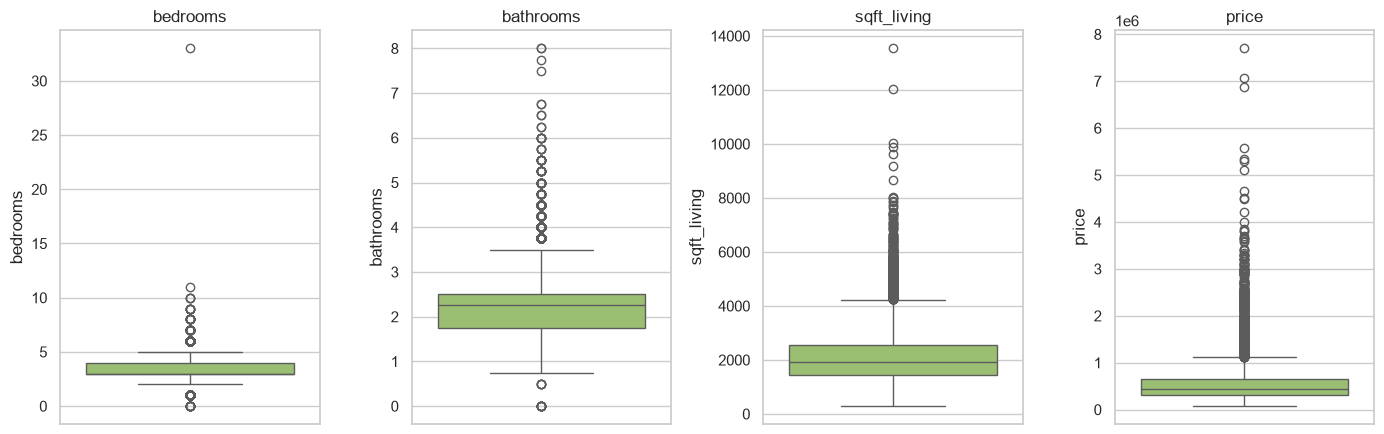

               id  bedrooms  bathrooms  sqft_living      price
15870  2402100895        33       1.75         1620 640,000.00
8757   1773100755        11       3.00         3000 520,000.00
19254  8812401450        10       3.00         2920 660,000.00


In [87]:
# --- Detecção de outliers com boxplots ---
plot_boxplots(df, ["bedrooms", "bathrooms", "sqft_living", "price"], filename="04_boxplots_outliers.png")

# Suspeita: um imóvel com número de quartos muito fora do padrão
print(df.sort_values("bedrooms", ascending=False)[["id", "bedrooms", "bathrooms", "sqft_living", "price"]].head(3))

**Justificativa (outliers):** o boxplot de `bedrooms` expõe um registro com **33 quartos** em um
imóvel de apenas 1.620 sqft (cerca de 150 m²) de área construída, o que é fisicamente improvável
(seria menos de 5 m² por quarto) e tudo indica ser um erro de digitação (provavelmente "3", não
"33"). Por isso, `bedrooms` foi tratada com **winsorização por IQR** (os valores fora do intervalo
aceitável são limitados ao limite superior/inferior), o que resolve esse caso específico sem
descartar a linha inteira.

Já os outliers de `price`, `sqft_living` e `bathrooms` foram **mantidos sem alteração**: eles
representam imóveis de alto padrão e não erros de coleta.
Remover ou limitar esses valores tenderia a fazer o modelo subestimar os imóveis
mais caros, que é justamente a faixa de preço em que uma estimativa ruim tem maior impacto
financeiro.

In [88]:
# cap_iqr (definida em src/features.py) aplica a winsorização por IQR:
# valores fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR] são limitados ao limite mais
# mais próximo podendo ser superior ou inferior, em vez de removidos.

print("Tratamento de outliers em 'bedrooms':")
q1, q3 = df["bedrooms"].quantile(0.25), df["bedrooms"].quantile(0.75)
iqr = q3 - q1
limite_inf, limite_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = ((df["bedrooms"] < limite_inf) | (df["bedrooms"] > limite_sup)).sum()
print(f"  limite=[{limite_inf:.1f}, {limite_sup:.1f}]  outliers tratados={outliers}")

df["bedrooms"] = cap_iqr(df["bedrooms"])
print("\nNovo máximo de bedrooms:", df["bedrooms"].max())

Tratamento de outliers em 'bedrooms':
  limite=[1.5, 5.5]  outliers tratados=546

Novo máximo de bedrooms: 5.5


## Fase 3 - Feature Engineering (Coluna Calculada)

In [89]:
# add_features (definida em src/features.py) cria as colunas derivadas:
# - ano_venda: extraído da coluna 'date' (formato "AAAAMMDDT000000")
# - idade_imovel: idade do imóvel no momento da venda
# - foi_reformado: indicador (0/1) derivado de yr_renovated
# - preco_por_m2: apenas para leitura/comparação exploratória entre imóveis.
#   Atenção (data leakage/vazamento de dados): esta coluna, preco_por_m2, deriva diretamente de 'price' (a própria
#   variável alvo). Por isso, ela nunca deve entrar como variável preditora do
#   modelo, isso daria ao modelo acesso indireto ao valor que ele deveria prever.

df = add_features(df)

print(df[["date", "yr_built", "idade_imovel", "yr_renovated", "foi_reformado",
          "price", "sqft_living", "preco_por_m2"]].head())

              date  yr_built  idade_imovel  yr_renovated  foi_reformado  \
0  20141013T000000      1955            59             0              0   
1  20141209T000000      1951            63          1991              1   
2  20150225T000000      1933            82             0              0   
3  20141209T000000      1965            49             0              0   
4  20150218T000000      1987            28             0              0   

       price  sqft_living  preco_por_m2  
0 221,900.00         1180        188.05  
1 538,000.00         2570        209.34  
2 180,000.00          770        233.77  
3 604,000.00         1960        308.16  
4 510,000.00         1680        303.57  


In [90]:
# Salva o dataframe já limpo (Fase 2) e com as features derivadas
# (Fase 3), usando save_processed_data de src/dataset.py. Isso permite
# inspecionar esse estado intermediário do pipeline, ou retomar a partir
# dele, sem precisar reprocessar o dataset bruto do zero.

save_processed_data(df)

Dataset processado salvo em: C:\Users\lapri\OneDrive\Desktop\SCTEC- GUILLERMO\Projeto_Final_Modulo-1\data\processed\kc_house_processed.csv


## Fase 4 - Preparação para Modelagem

**Sobre codificação (encoding):** colunas como `waterfront` (0/1), `view` e `condition` (escalas
ordinais de 0 a 5) já estão representadas como números inteiros com uma ordem que faz sentido
(por exemplo, `condition=5` é de fato "melhor" que `condition=1`), então não precisam de encoding
adicional. Já `zipcode` é diferente: é uma variável **nominal** (não existe uma ordem natural
entre os códigos - `98004` não é "maior" que `98001` em nenhum sentido relevante para o preço) e
tem mais de 70 valores únicos, então aplicar One-Hot Encoding diretamente geraria dezenas de colunas
esparsas. Em vez disso, os zipcodes foram agrupados em 10 faixas conforme o preço médio de venda
dos imóveis daquela região (uma técnica chamada *target encoding*), e essas faixas é que fazemos
one-hot encoding.

**Atenção (vazamento de dados):** o preço médio por zipcode só pode ser calculado usando os dados
de **treino**. Calculá-lo antes da divisão treino/teste (ou usando o dataset inteiro) faz com que
essa variável "enxergue" o preço de imóveis que deveriam estar no conjunto de teste, inflando
artificialmente as métricas do modelo. Por isso, a divisão treino/teste é feita **antes** do encoding de zipcode nesta
seção.

In [91]:
# Conjunto de variáveis explicativas/preditoras que vamos usar (não precisamos incluir id, date, price e preco_por_m2).
# 'zipcode' entra aqui ainda em formato bruto; será transformada logo abaixo.
explicativas = ["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront",
              "view", "condition", "grade", "sqft_above", "sqft_basement", "sqft_living15",
              "sqft_lot15", "idade_imovel", "foi_reformado", "lat", "long", "zipcode"]

X = df[explicativas].copy()
y = df["price"].copy()

# Divisão treino/teste (80/20), feita antes do encoding de zipcode para evitar vazamento. 
# Fixamos random_state para reprodutibilidade.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino: {X_train.shape}   Teste: {X_test.shape}")

Treino: (17290, 18)   Teste: (4323, 18)


In [92]:
# Salva o dataframe final usado na modelagem: apenas as variáveis
# explicativas + o alvo (select_final_columns, de src/features.py), antes do
# split e do encoding de zipcode - que dependem de como os dados são
# divididos em cada execução
df_final = select_final_columns(df, explicativas, "price")
save_final_data(df_final)

Dataset final salvo em: C:\Users\lapri\OneDrive\Desktop\SCTEC- GUILLERMO\Projeto_Final_Modulo-1\data\final\kc_house_final.csv


In [93]:
# zipcode aqui é como um nome de bairro escrito em números, precisa ser "traduzido" para algo que capture a ideia de 
# "bairros caros vs. bairros baratos" antes de entrar no modelo. Preço médio de venda por zipcode, calculado SOMENTE 
# com o conjunto de treino.

preco_medio_por_zip = y_train.groupby(X_train["zipcode"]).mean()

# pd.qcut divide os zipcodes em 10 grupos de tamanho aproximadamente igual
# (quantis), ordenados do preço médio mais baixo ("faixa_0") ao mais alto
# ("faixa_9"). É como pegar todos os bairros, ordená-los do mais barato ao
# mais caro, e cortar essa fila em 10 pedaços iguais - cada pedaço vira uma
# categoria. Isso resolve o problema de zipcode ter 70+ valores sem ordem
# numérica útil, condensando tudo em 10 faixas ordenadas
# por preço de imóveis da região. duplicates="drop" evita erro caso dois cortes 
# caiam exatamente no mesmo valor de preço.

faixa_zip = pd.qcut(preco_medio_por_zip, 10, labels=[f"faixa_{i}" for i in range(10)], duplicates="drop")

# mapa_zip é um dicionário {zipcode: faixa}, ex.: {98001: "faixa_2", 98004: "faixa_9", ...}
# usado logo abaixo para "traduzir" cada zipcode bruto na sua faixa de preço.

mapa_zip = faixa_zip.to_dict()

# mapa_zip só conhece os zipcodes que apareceram no treino. Como o
# train_test_split é aleatório, é possível que um zipcode raro no dataset
# caia inteiramente no teste e nunca apareça no treino - nesse caso, ele não
# tem entrada em mapa_zip. Na linha seguinte, tentar traduzir esse zipcode
# desconhecido resultaria em NaN, e a Regressão Linear não aceita valores
# nulos. Por isso, calculamos aqui uma faixa de resposta padrão para usar
# nesses casos: a faixa que mais se repete entre os zipcodes do treino -
# uma aposta razoável quando não sabemos a faixa real do bairro.

faixa_mais_comum = faixa_zip.mode()[0]  # resposta padrão para zipcode "novo" no teste

# Aplica a tradução: cada zipcode bruto (ex.: 98115) é substituído pela sua
# faixa de preço (ex.: "faixa_7"). No teste, qualquer zipcode sem correspondência
# no dicionário (não visto no treino) recebe a faixa mais comum em vez de ficar nulo.

X_train["zipcode_faixa"] = X_train["zipcode"].map(mapa_zip)
X_test["zipcode_faixa"] = X_test["zipcode"].map(mapa_zip).fillna(faixa_mais_comum)
print("Zipcodes do teste sem correspondência no treino (usam a faixa mais comum):",
      X_test["zipcode"].map(mapa_zip).isna().sum())

# One-hot encoding: transforma a coluna categórica "zipcode_faixa"
# ex.: "faixa_0".."faixa_9" em várias colunas numéricas 0/1, uma por faixa,
# porque a Regressão Linear só aceita números como entrada. drop_first=True
# descarta a primeira faixa (faixa_0) para evitar redundância: se um imóvel
# tem 0 em todas as outras faixas, o modelo já sabe implicitamente que ele
# pertence à faixa_0, sem precisar de uma coluna extra só para isso.

X_train = pd.get_dummies(X_train.drop(columns="zipcode"), columns=["zipcode_faixa"], drop_first=True)
X_test = pd.get_dummies(X_test.drop(columns="zipcode"), columns=["zipcode_faixa"], drop_first=True)

# Como o one-hot encoding é feito separadamente em treino e teste, é possível
# que uma faixa apareça em um conjunto e não no outro (ex.: nenhum imóvel dos
# dados de teste caiu na faixa_3), gerando colunas diferentes nos dois lados. O reindex
# alinha X_test às colunas exatas de X_train, preenchendo com 0 qualquer coluna
# ausente - garantindo que os dois conjuntos tenham as mesmas "colunas" para o modelo.

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
print(f"\nQuantidade de variaveis explicativas após o encoding de zipcode: {X_train.shape[1]}")

Zipcodes do teste sem correspondência no treino (usam a faixa mais comum): 0

Quantidade de variaveis explicativas após o encoding de zipcode: 26


In [94]:
# Correlação entre as próprias variáveis explicativas (não com o alvo) para localizar pares redundantes antes de calcular o VIF.

corr_x = X_train.corr(numeric_only=True)
pares_redundantes = corr_x.where(np.triu(np.ones(corr_x.shape), k=1).astype(bool)).stack()
print("Pares de variáveis explicativas com correlação > 0.7:")
print(pares_redundantes[pares_redundantes.abs() > 0.7].sort_values(ascending=False))

Pares de variáveis explicativas com correlação > 0.7:
sqft_living  sqft_above      0.88
             grade           0.76
             sqft_living15   0.75
grade        sqft_above      0.75
bathrooms    sqft_living     0.75
sqft_lot     sqft_lot15      0.73
sqft_above   sqft_living15   0.73
grade        sqft_living15   0.71
dtype: float64


`sqft_living` está fortemente correlacionada com `sqft_above` (0.88), `grade` (0.76) e
`sqft_living15` (0.75). Isso faz sentido: `sqft_above` é praticamente `sqft_living` menos o porão,
e `sqft_living15` é a área construída dos imóveis vizinhos em 2015 (uma versão "suavizada" da
própria variável). Da mesma forma, `sqft_lot` e `sqft_lot15` medem quase a mesma coisa (área do
terreno). 
Manter todas essas colunas juntas infla artificialmente o VIF de `sqft_living` sem
agregar informação nova ao modelo. Por isso, `sqft_above`, `sqft_living15` e `sqft_lot15` foram
removidas antes mesmo de calcular o VIF, mantendo `sqft_living`, `sqft_lot` e `sqft_basement`
como as medidas de tamanho do imóvel.

In [95]:
colunas_redundantes = ["sqft_above", "sqft_living15", "sqft_lot15"]
X_train = X_train.drop(columns=colunas_redundantes).astype(float)
X_test = X_test.drop(columns=colunas_redundantes).astype(float)

# Cálculo do VIF (Fator de Inflação da Variância). É preciso adicionar uma
# constante (intercepto) antes de calcular o VIF - sem ela, variáveis que não
# passam perto de zero (como lat/long) recebem um VIF artificialmente enorme.
X_vif = sm.add_constant(X_train)
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const")
print("VIF por variável (valores acima de 10 indicam multicolinearidade relevante):")
print(vif.sort_values(ascending=False))

VIF por variável (valores acima de 10 indicam multicolinearidade relevante):
sqft_living             5.12
zipcode_faixa_faixa_7   4.23
zipcode_faixa_faixa_6   3.93
zipcode_faixa_faixa_5   3.83
zipcode_faixa_faixa_3   3.54
zipcode_faixa_faixa_8   3.51
grade                   3.42
bathrooms               3.36
lat                     2.98
zipcode_faixa_faixa_9   2.93
zipcode_faixa_faixa_4   2.92
zipcode_faixa_faixa_2   2.77
idade_imovel            2.53
zipcode_faixa_faixa_1   2.25
floors                  2.06
sqft_basement           1.96
bedrooms                1.73
long                    1.65
view                    1.39
condition               1.24
waterfront              1.20
foi_reformado           1.15
sqft_lot                1.13
dtype: float64


**Justificativa (multicolinearidade):** após remover as três colunas redundantes, todos os VIFs
ficaram abaixo de 5.2 (o maior é `sqft_living`), um nível considerado aceitável - inclusive as 9
colunas de `zipcode_faixa` recém-criadas, que não introduziram multicolinearidade relevante com
`lat`/`long`. Isso mostra que a localização "fina" (latitude/longitude) e a localização "em
faixa de preço" (zipcode agrupado) carregam informação complementar, não redundante, e por isso
as duas foram mantidas no modelo.

In [96]:
# Escalonamento: para a Regressão Linear, o escalonamento não é obrigatório
# para a qualidade da predição, mas ajuda a comparar a magnitude dos coeficientes
# entre variáveis com escalas muito diferentes (ex.: sqft_living na casa dos
# milhares vs. bathrooms de 0 a 8, ou as colunas de zipcode_faixa, que são 0/1).
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print("Total de variaveis explicativas/features utilizadas no modelo:", X_train.shape[1])
print(list(X_train.columns))

Total de variaveis explicativas/features utilizadas no modelo: 23
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_basement', 'idade_imovel', 'foi_reformado', 'lat', 'long', 'zipcode_faixa_faixa_1', 'zipcode_faixa_faixa_2', 'zipcode_faixa_faixa_3', 'zipcode_faixa_faixa_4', 'zipcode_faixa_faixa_5', 'zipcode_faixa_faixa_6', 'zipcode_faixa_faixa_7', 'zipcode_faixa_faixa_8', 'zipcode_faixa_faixa_9']


## Fase 5 - Modelagem, Validação e Diagnóstico de Overfitting

In [97]:
# train_model, train_knn_model, evaluate_model e evaluate_model2  (definidas em src/modeling/train.py) treinam os medelos
# de Regressão Linear e KNN, calculam MAE, MSE, RMSE e R2 para um conjunto de previsões.

lr = train_model(X_train_s, y_train) # pyright: ignore[reportArgumentType]
pred_train = lr.predict(X_train_s)
pred_test = lr.predict(X_test_s)
met_treino = evaluate_model(lr, X_train_s, y_train)
met_teste = evaluate_model(lr, X_test_s, y_test)

knn = train_knn_model((X_train_s, y_train))
pred_treino2 = knn.predict(X_train_s)
pred_test2 = knn.predict(X_test_s)
met_treino2 = evaluate_model2(knn, X_train_s, y_train)
met_teste2 = evaluate_model2(knn, X_test_s, y_test)

print(f"{'Métrica':<8}{'RL Treino':>15}{'RL Teste':>15}{'KNN Treino':>15}{'KNN Teste':>15}")
print("-"*68)

for m in met_treino.keys():

    if m == "R2":
        print(f"{m:<8}"
              f"{met_treino[m]:>15.3f}"
              f"{met_teste[m]:>15.3f}"
              f"{met_treino2[m]:>15.3f}"
              f"{met_teste2[m]:>15.3f}")
    else:
        print(f"{m:<8}"
              f"{met_treino[m]:>15,.0f}"
              f"{met_teste[m]:>15,.0f}"
              f"{met_treino2[m]:>15,.0f}"
              f"{met_teste2[m]:>15,.0f}")


Métrica       RL Treino       RL Teste     KNN Treino      KNN Teste
--------------------------------------------------------------------
MAE             104,551        108,991         84,331         93,921
MSE      30,302,296,089 36,736,282,141 26,944,965,557 35,586,806,900
RMSE            174,076        191,667        164,149        188,645
R2                0.768          0.757          0.794          0.765


**Diagnóstico de overfitting:** o RMSE de treino (~US 174.076/164.149) e o de teste (~US 191.667/188.645) ficam próximos para ambos os modelos, assim como o R2 de treino (0.768/0.794) e de teste (0.757/0.765). Uma diferença pequena entre treino e teste é evidência de que os modelos **não estão sofrendo overfitting**: eles generalizam para dados novos com uma qualidade muito parecida com a que teve nos dados de treino.

## Fase 6 - Avaliação do modelo campeao

In [98]:
# Comparação automática entre regressão linear e KNN usando R2 em teste

modelos = {
    "Regressão Linear": {
        "modelo": lr,
        "pred": pred_test,
        "metricas": met_teste,
    },
    "KNN": {
        "modelo": knn,
        "pred": pred_test2,
        "metricas": met_teste2,
    },
}

# 1. Comparação entre modelos candidatos
print("\nComparação de modelos (conjunto de teste)")
print("-" * 68)
print(f"{'Métrica':<10}{'RL':>15}{'KNN':>15}{'Vencedor':>20}")
print("-" * 68)

for m in met_teste.keys():
    v_rl = met_teste[m]
    v_knn = met_teste2[m]

    if m == "R2":
        melhor = "RL" if v_rl > v_knn else "KNN"
        print(f"{m:<10}{v_rl:>15.3f}{v_knn:>15.3f}{melhor:>20}")
    else:
        melhor = "RL" if v_rl < v_knn else "KNN"
        print(f"{m:<10}{v_rl:>15,.0f}{v_knn:>15,.0f}{melhor:>20}")

# 2. Modelo campeão

nome_campeao = max(
    modelos,
    key=lambda k: modelos[k]["metricas"]["R2"]
)

metricas_campeao = modelos[nome_campeao]["metricas"]

print(f"\nCritério: maior R² em teste ({metricas_campeao['R2']:.3f})")

print("\n")
print(f"Modelo campeão selecionado: {nome_campeao}")

print(f"{'Métricas':<10}{'Valor':>15}")
print("-" * 25)

for m, v in metricas_campeao.items():
    if m == "R2":
        print(f"{m:<10}{v:>15.3f}")
    else:
        print(f"{m:<10}{v:>15,.0f}")


Comparação de modelos (conjunto de teste)
--------------------------------------------------------------------
Métrica                RL            KNN            Vencedor
--------------------------------------------------------------------
MAE               108,991         93,921                 KNN
MSE        36,736,282,141 35,586,806,900                 KNN
RMSE              191,667        188,645                 KNN
R2                  0.757          0.765                 KNN

Critério: maior R² em teste (0.765)


Modelo campeão selecionado: KNN
Métricas            Valor
-------------------------
MAE                93,921
MSE        35,586,806,900
RMSE              188,645
R2                  0.765


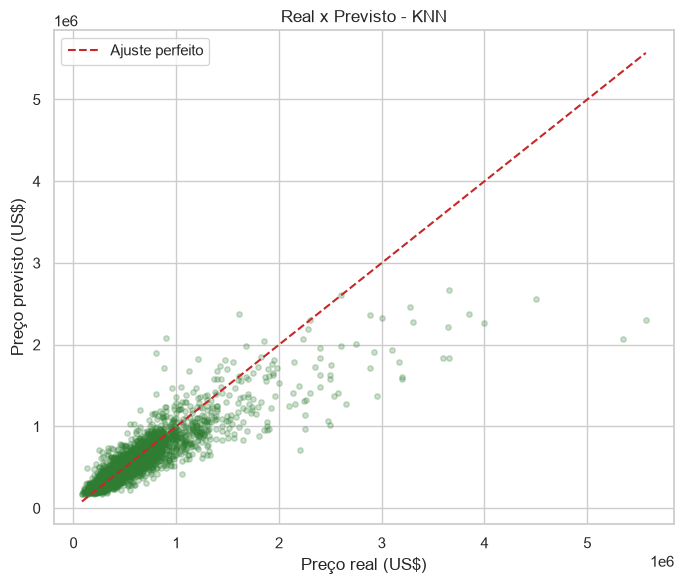

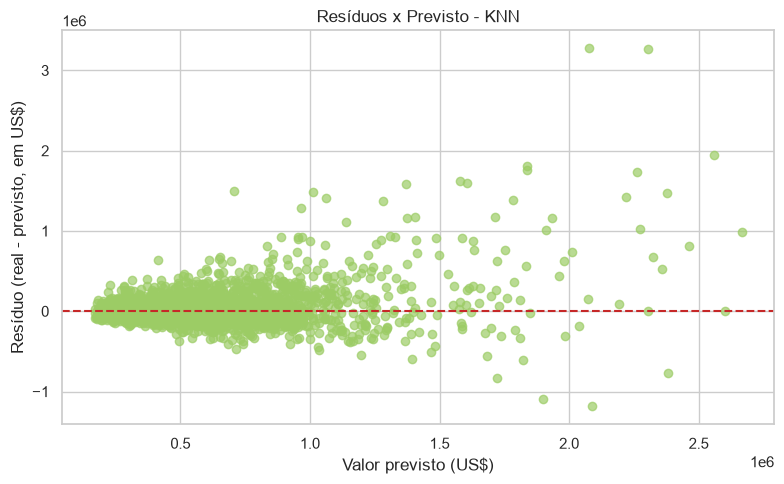

Resíduo médio: US$ 25,409   |   Desvio padrão do resíduo: US$ 186,947


In [99]:
# Gráfico 1: valores reais x valores previstos (quanto mais próximos da diagonal, melhor)
campeao = modelos[nome_campeao]
modelo_campeao = campeao["modelo"]
pred_campeao = campeao["pred"]
metricas_campeao = campeao["metricas"]

plot_observed_vs_predicted(y_test, pred_campeao, f"Real x Previsto - {nome_campeao}",
                            "07_observado_vs_previsto.png")

# Gráfico 2: resíduos (erro = valor real - valor previsto) versus valores previstos.
# Útil para checar heterocedasticidade: se o "espalhamento" dos pontos aumenta ou
# diminui conforme o valor previsto cresce, é sinal de que o erro do modelo não é
# constante ao longo da faixa de preços.
residuos = plot_residuals(y_test, pred_campeao, f"Resíduos x Previsto - {nome_campeao}",
                           "08_residuos.png")

print(f"Resíduo médio: US$ {residuos.mean():,.0f}   |   Desvio padrão do resíduo: US$ {residuos.std():,.0f}")

**Veredito de negócio:** em média, o modelo campeão (KNN) erra cerca de US 93,921 na estimativa de um imóvel(MAE de teste), o que corresponde a aproximadamente 21% da mediana de preço do dataset (US 450mil). O RMSE de teste é bem mais alto (~US 188.645), e essa diferença entre MAE e RMSE não é um erro de leitura: como o RMSE eleva os erros ao quadrado antes de tirar a média, ele penaliza
muito mais os poucos casos em que o modelo erra feio, enquanto o MAE reflete melhor o erro típico do dia a dia. Ou seja, na maioria 
das vendas o modelo erra por volta de US$ 94 mil, mas existe umgrupo pequeno de imóveis em que o erro é bem maior, e é esse grupo que 
puxa o RMSE para cima.

Essa margem é grande demais para poder embasar uma decisão de financiamento bancário, mas jáé útil como uma primeira estimativa de referência para comprador ou vendedor compararem com o valor pedido, ou como um "sinal de alerta" quando o preço anunciado está muito 
fora da faixa prevista pelo modelo. O gráfico de resíduos por valor previsto mostra que os erros se concentram perto de zero, mas com 
maior dispersão nos imóveis de valor mais alto, um indício de heterocedasticidade,e reflexo dos mesmos outliers de `price` que decidimos manter na Fase 2 (são justamente eles que fazem o RMSE ficar tão acima do MAE).


## Fase 7 - Retreino do Modelo Final com 100% dos Dados

**Por que retreinar:** até aqui, o medelo foi treinado usando apenas os 80% de treino - o que é
necessário para obter uma estimativa **honesta** de erro em dados nunca vistos (as métricas de
teste calculadas na Fase 5, que continuam sendo as métricas reportadas no "Veredito de negócio"
acima). 
Mas o modelo que efetivamente é salvo para uso não deveria ficar restrito a apenas 80%
dos dados: uma vez que já validamos a capacidade de generalização do modelo através do teste, não
há mais motivo para reservar essa fatia - e treinar com **todos** os dados disponíveis (treino +
teste),  para obter um modelo final mais robusto, sem custar nada em termos de honestidade da
avaliação (que já foi feita antes, e cujos números continuam valendo como estimativa de erro
esperado).

In [100]:
# Reaplica o mesmo encoding de zipcode usado na Fase 4, mas agora ajustado
# (fit) com a base inteira (X, y - o dataset completo, antes do split),
# usando as funções reutilizáveis de src/features.py. colunas_referencia
# garante que o resultado tenha exatamente as mesmas colunas de X_train
# (mesma ordem, mesmas faixas), para manter o modelo final consistente com
# o que foi avaliado na Fase 5.

mapa_zip_final, faixa_mais_comum_final = fit_zipcode_faixas(X, y, n_faixas=10)
X_full = apply_zipcode_faixas(X, mapa_zip_final, faixa_mais_comum_final, colunas_referencia=X_train.columns)
X_full = X_full.astype(float)

# Escalonamento ajustado com a base inteira - um scaler novo, específico do
# modelo final (diferente do "scaler" da Fase 4, que foi ajustado só com o
# treino e serviu apenas para a avaliação honesta feita na Fase 5).

scaler_final = StandardScaler()
X_full_s = scaler_final.fit_transform(X_full)

# Retreino: mesmo algoritmo do modelo campeão (selecionado anteriormente),
# agora usando 100% dos dados.

if nome_campeao == "Regressão Linear":
    modelo_final = train_model(X_full_s, y)
elif nome_campeao == "KNN":
    modelo_final = train_knn_model((X_full_s, y))
else:
    raise ValueError(f"Modelo campeão desconhecido: {nome_campeao}")

print(f"Modelo final ({nome_campeao}) retreinado com {X_full_s.shape[0]} imóveis (100% da base, treino + teste).")


# Previsões do modelo treinado com 100% dos dados
y_pred = modelo_final.predict(X_full_s)

# métricas modelo retreinado
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\nMétricas do modelo final")
print("-" * 35)
print(f"{'Métrica':<15}{'Valor':>12}")
print("-" * 35)
print(f"{'MAE':<15}      {mae:>12,.3f}")
print(f"{'MSE':<15}{mse:>12,.3f}")
print(f"{'RMSE':<15}      {rmse:>12,.3f}")
print(f"{'R²':<15}      {r2:>12,.3f}")
print("-" * 35)


Modelo final (KNN) retreinado com 21613 imóveis (100% da base, treino + teste).

Métricas do modelo final
-----------------------------------
Métrica               Valor
-----------------------------------
MAE                    82,102.653
MSE            25,339,178,027.445
RMSE                  159,182.845
R²                          0.812
-----------------------------------


## Fase 8 Interpretação e Versionamento do Modelo final.

In [101]:
# Versionamento do modelo: salva o modelo FINAL (retreinado com 100% dos
# dados na Fase 7) e as métricas de avaliação honesta (calculadas no split
# 80/20 da Fase 5) em models/v1/, usando save_model e save_metrics de
# src/modeling/train.py.
# Versionamento do modelo: salva o modelo FINAL (retreinado com 100% dos
# dados na Fase 7) e as métricas de avaliação honesta (calculadas no split
# 80/20 da Fase 5) em models/v1, usando save_model e save_metrics de
# src/modeling/train.py.
metricas_v1 = {
    "versao": "v1",
    "modelo_salvo": nome_campeao,
    "data_treinamento": datetime.now().strftime("%Y-%m-%d"),
    "treinado_com": ("100% da base (treino + teste) - retreino final feito na Fase 6a, "
                      "após a avaliação honesta da Fase 5"),
    "features_utilizadas": list(X_train.columns),
    "scaler": ("StandardScaler reajustado com 100% da base para o modelo final salvo "
               "(scaler_final da Fase 6a). As métricas abaixo, porém, vêm do modelo "
               "avaliado apenas no split 80/20 (Fase 5), pois é a única forma honesta "
               "de estimar o erro do modelo em dados nunca vistos."),
    "metricas_modelo_salvo": {
        "treino": {k: float(v) for k, v in met_treino.items()},
        "teste": {k: float(v) for k, v in metricas_campeao.items()},
    },
}

# save_model guarda usando el nombre del modelo campeão -> "<nome_campeao>.pkl"
save_model(modelo_final, nome_campeao)
save_metrics(metricas_v1)

MODEL_FILE = os.path.join(MODEL_DIR, f"{nome_campeao}.pkl")  
METRICS_FILE = os.path.join(MODEL_DIR, "metricas_v1.json")

# Verificação antes do carregamento
if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(f"No se encontró el modelo en: {MODEL_FILE}")
if not os.path.exists(METRICS_FILE):
    raise FileNotFoundError(f"No se encontró el archivo de métricas en: {METRICS_FILE}")

# Leitura de volta para confirmar que os arquivos foram gravados corretamente
modelo_recarregado = joblib.load(MODEL_FILE)
with open(METRICS_FILE, encoding="utf-8") as f:
    metricas_recarregadas = json.load(f)

Modelo campeão (KNN) salvo em: C:\Users\lapri\OneDrive\Desktop\SCTEC- GUILLERMO\Projeto_Final_Modulo-1\models\v1\KNN.pkl
Métricas salvas em: C:\Users\lapri\OneDrive\Desktop\SCTEC- GUILLERMO\Projeto_Final_Modulo-1\models\v1\metricas_v1.json


In [102]:
# Leitura de volta para confirmar que os arquivos foram gravados corretamente

    
print("="*68)
print(" RELATÓRIO FINAL — SELEÇÃO E VERSIONAMENTO DO MODELO")
print("="*68)

# 1. Modelo campeão
print(f"Modelo campeão selecionado: {nome_campeao}")
print(f"Critério: maior R² em teste ({metricas_campeao['R2']:.3f})")

# métricas modelo retreinado
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\nMétricas do modelo retreinado (lidas do arquivo salvo)")
print(f"MAE : {mae:,.3f}")
print(f"MSE: {mse:,.3f}")
print(f"RMSE: {rmse:,.3f}")
print(f"R²  : {r2:.3f}")

# 2. Metadados de versionamento
print("\nInformações de versionamento")
print("-"*68)
print(f"Versão salva:        {metricas_recarregadas['versao']}")
print(f"Modelo salvo:        {metricas_recarregadas['modelo_salvo']}")
print(f"Data de treinamento: {metricas_recarregadas['data_treinamento']}")
print(f"Treinado com:        {metricas_recarregadas['treinado_com']}")
print(f"Nº de features:      {len(metricas_recarregadas['features_utilizadas'])}")
print(f"Scaler:              {metricas_recarregadas['scaler']}")

# 4. Features utilizadas
features = metricas_recarregadas['features_utilizadas']
print(f"\nFeatures utilizadas ({len(features)} no total)")
print("-"*68)
for i, f in enumerate(features, 1):
    print(f"  {i:>2}. {f}")
print("="*68)



 RELATÓRIO FINAL — SELEÇÃO E VERSIONAMENTO DO MODELO
Modelo campeão selecionado: KNN
Critério: maior R² em teste (0.765)

Métricas do modelo retreinado (lidas do arquivo salvo)
MAE : 82,102.653
MSE: 25,339,178,027.445
RMSE: 159,182.845
R²  : 0.812

Informações de versionamento
--------------------------------------------------------------------
Versão salva:        v1
Modelo salvo:        KNN
Data de treinamento: 2026-07-19
Treinado com:        100% da base (treino + teste) - retreino final feito na Fase 6a, após a avaliação honesta da Fase 5
Nº de features:      23
Scaler:              StandardScaler reajustado com 100% da base para o modelo final salvo (scaler_final da Fase 6a). As métricas abaixo, porém, vêm do modelo avaliado apenas no split 80/20 (Fase 5), pois é a única forma honesta de estimar o erro do modelo em dados nunca vistos.

Features utilizadas (23 no total)
--------------------------------------------------------------------
   1. bedrooms
   2. bathrooms
   3. sqft_li